In [3]:
# Setup visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Phase one - situation analysis
# paharmaLens 


# importing libraries 
import pandas as pd 
import numpy as np 


plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "Arial"
sns.set_theme(style="whitegrid")

print("Visualization libraries ready!")

Visualization libraries ready!


In [16]:
#load the DS
dataset_path="E:\PharmaLens\data\Pharma_BI_Dataset_v3.xlsx"



# i just added the header cause the first row is the title of the sheet, so I just needed to tell that the names of the columns are in row 2 
sales = pd.read_excel(dataset_path , sheet_name="Sales Transactions" , header=1)

expenses = pd.read_excel(dataset_path , sheet_name="Expenses" , header=1)
dept = pd.read_excel(dataset_path , sheet_name="Debt & AR" ,  header=1)
inventory = pd.read_excel(dataset_path , sheet_name="Inventory (HQ)",header=1)




print("Data Loaded sucessfully!!")
print(f"sales rows : {len(sales):,}")
print(f"Expenses rows : {len(expenses):,}")
print(f"Dept rows : {len(dept):,}")
print(f"Inventory rows : {len(inventory):,}")







<>:2: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:2: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\FreeComp\AppData\Local\Temp\ipykernel_16072\2627942656.py:2: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  dataset_path="E:\PharmaLens\data\Pharma_BI_Dataset_v3.xlsx"


Data Loaded sucessfully!!
sales rows : 11,713
Expenses rows : 1,200
Dept rows : 172
Inventory rows : 4


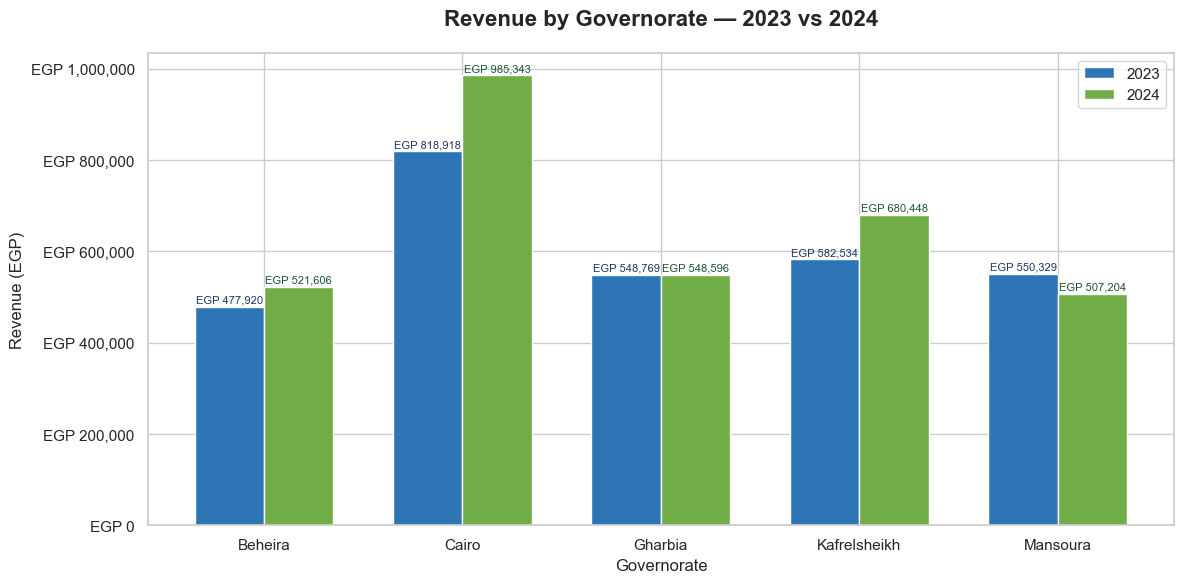

In [17]:
# Chart 1 — Revenue by Governorate 2023 vs 2024
gov_yearly = sales.groupby(["Governorate", "Year"])["Total Revenue EGP"].sum().reset_index()

gov_pivot = gov_yearly.pivot(index="Governorate", columns="Year", values="Total Revenue EGP")

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(gov_pivot.index))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], gov_pivot[2023], width, 
               label="2023", color="#2E75B6", edgecolor="white")
bars2 = ax.bar([i + width/2 for i in x], gov_pivot[2024], width, 
               label="2024", color="#70AD47", edgecolor="white")

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f"EGP {bar.get_height():,.0f}", ha="center", va="bottom", 
            fontsize=8, color="#1F3864")

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f"EGP {bar.get_height():,.0f}", ha="center", va="bottom", 
            fontsize=8, color="#1E5631")

ax.set_title("Revenue by Governorate — 2023 vs 2024", 
             fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Governorate", fontsize=12)
ax.set_ylabel("Revenue (EGP)", fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(gov_pivot.index, fontsize=11)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"EGP {v:,.0f}"))

plt.tight_layout()
plt.savefig("../visuals/01_revenue_by_governorate.png", dpi=150)
plt.show()


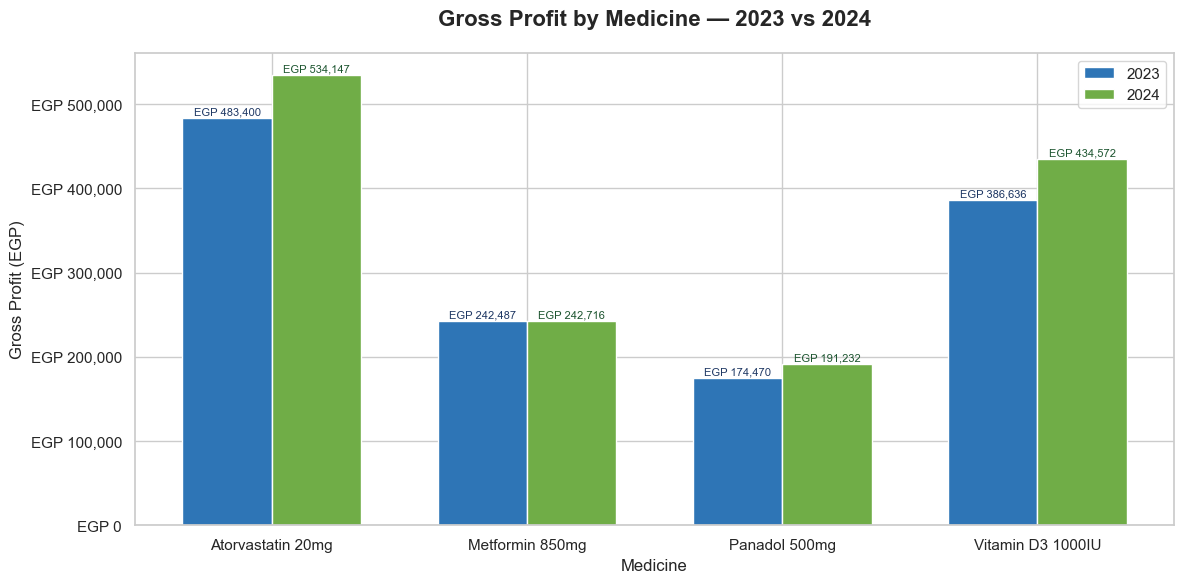

In [9]:
# Chart 2 — Profit by Medicine 2023 vs 2024


med_yearly = sales.groupby(["Medicine Name", "Year"])["Gross Profit EGP"].sum().reset_index()

med_pivot = med_yearly.pivot(index="Medicine Name", columns="Year", values="Gross Profit EGP")

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(med_pivot.index))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], med_pivot[2023], width,
               label="2023", color="#2E75B6", edgecolor="white")
bars2 = ax.bar([i + width/2 for i in x], med_pivot[2024], width,
               label="2024", color="#70AD47", edgecolor="white")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f"EGP {bar.get_height():,.0f}", ha="center", va="bottom",
            fontsize=8, color="#1F3864")

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f"EGP {bar.get_height():,.0f}", ha="center", va="bottom",
            fontsize=8, color="#1E5631")

ax.set_title("Gross Profit by Medicine — 2023 vs 2024",
             fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Medicine", fontsize=12)
ax.set_ylabel("Gross Profit (EGP)", fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(med_pivot.index, fontsize=11)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"EGP {v:,.0f}"))

plt.tight_layout()
plt.savefig("../visuals/02_profit_by_medicine.png", dpi=150)
plt.show()


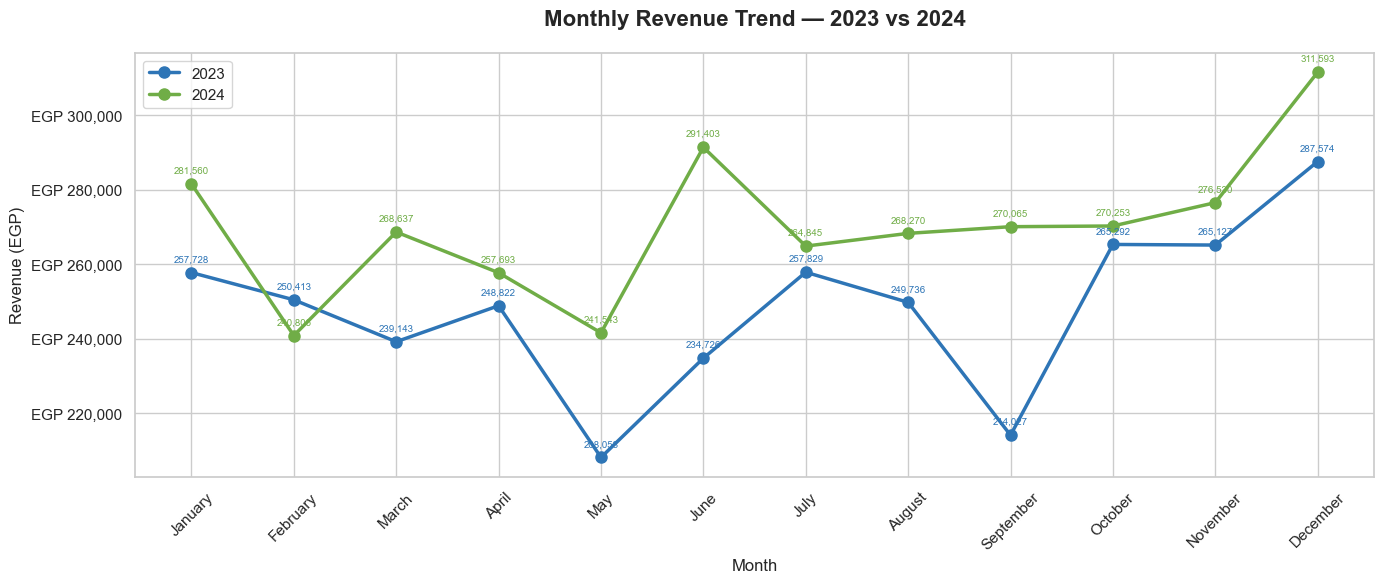

In [13]:
# Chart 3 — Monthly Revenue Trend 2023 vs 2024
monthly = sales.groupby(["Year", "Month", "Month Name"])["Total Revenue EGP"].sum().reset_index()
monthly = monthly.sort_values(["Year", "Month"])

data_2023 = monthly[monthly["Year"] == 2023]
data_2024 = monthly[monthly["Year"] == 2024]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(data_2023["Month Name"], data_2023["Total Revenue EGP"],
        marker="o", linewidth=2.5, color="#2E75B6", label="2023", markersize=8)

ax.plot(data_2024["Month Name"], data_2024["Total Revenue EGP"],
        marker="o", linewidth=2.5, color="#70AD47", label="2024", markersize=8)

# Add value labels
for _, row in data_2023.iterrows():
    ax.text(row["Month Name"], row["Total Revenue EGP"] + 3000,
            f"{row['Total Revenue EGP']:,.0f}", ha="center", fontsize=7, color="#2E75B6")

for _, row in data_2024.iterrows():
    ax.text(row["Month Name"], row["Total Revenue EGP"] + 3000,
            f"{row['Total Revenue EGP']:,.0f}", ha="center", fontsize=7, color="#70AD47")

ax.set_title("Monthly Revenue Trend — 2023 vs 2024",
             fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Revenue (EGP)", fontsize=12)
ax.legend(fontsize=11)
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"EGP {v:,.0f}"))

plt.tight_layout()
plt.savefig("../visuals/03_monthly_trend.png", dpi=150)
plt.show()


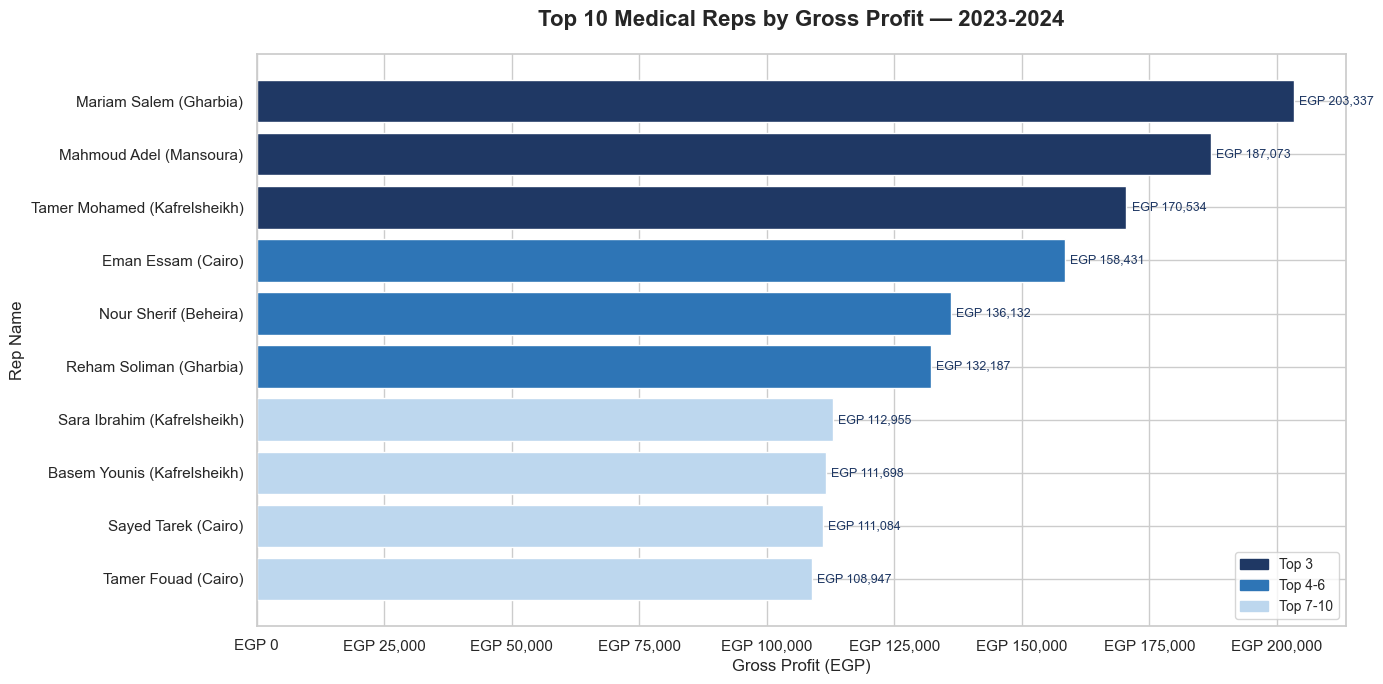

In [14]:
# Chart 4 — Top Medical Reps by Profit
rep_perf = sales.groupby(["Rep Name", "Governorate"]).agg(
    Total_Profit=("Gross Profit EGP", "sum"),
    Total_Revenue=("Total Revenue EGP", "sum")
).reset_index().sort_values("Total_Profit", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(14, 7))

colors = ["#1F3864" if i < 3 else "#2E75B6" if i < 6 else "#BDD7EE" 
          for i in range(len(rep_perf))]

bars = ax.barh(rep_perf["Rep Name"] + " (" + rep_perf["Governorate"] + ")",
               rep_perf["Total_Profit"], color=colors, edgecolor="white")

for bar in bars:
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f"EGP {bar.get_width():,.0f}", va="center", fontsize=9, color="#1F3864")

ax.set_title("Top 10 Medical Reps by Gross Profit — 2023-2024",
             fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Gross Profit (EGP)", fontsize=12)
ax.set_ylabel("Rep Name", fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"EGP {v:,.0f}"))
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend = [Patch(color="#1F3864", label="Top 3"),
          Patch(color="#2E75B6", label="Top 4-6"),
          Patch(color="#BDD7EE", label="Top 7-10")]
ax.legend(handles=legend, fontsize=10)

plt.tight_layout()
plt.savefig("../visuals/04_top_reps.png", dpi=150)
plt.show()


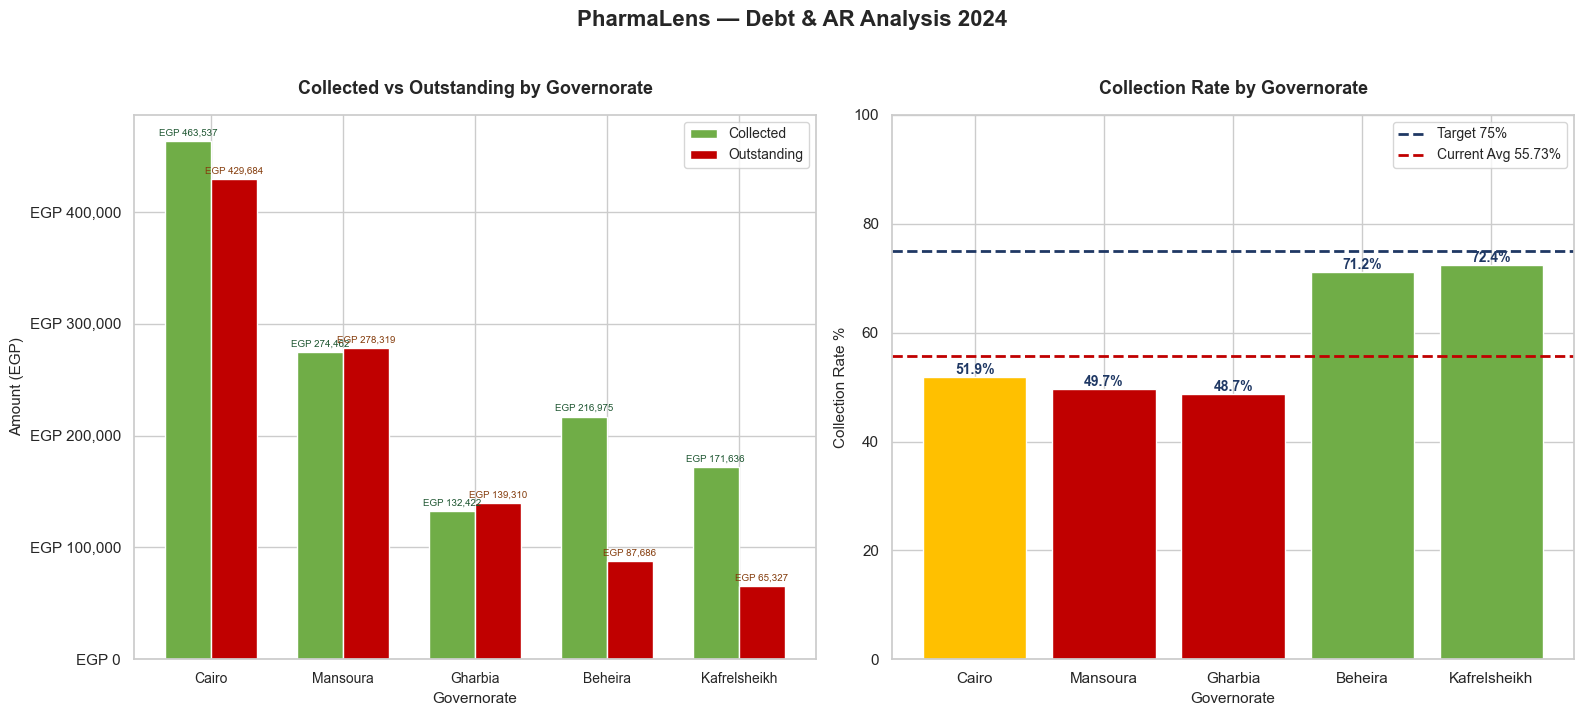

In [20]:
# Chart 5 — Debt Analysis by Governorate

dept = pd.read_excel(dataset_path , sheet_name="Debt & AR" ,  header=1)

debt_gov = dept.groupby("Governorate").agg(
    Total_Debt=("Invoice Amount EGP", "sum"),
    Total_Collected=("Collected EGP", "sum"),
    Total_Outstanding=("Outstanding EGP", "sum")
).reset_index()

debt_gov["Collection_Rate_%"] = (debt_gov["Total_Collected"] / debt_gov["Total_Debt"]) * 100
debt_gov = debt_gov.sort_values("Total_Outstanding", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left chart — Outstanding vs Collected
x = range(len(debt_gov))
width = 0.35

axes[0].bar([i - width/2 for i in x], debt_gov["Total_Collected"], width,
            label="Collected", color="#70AD47", edgecolor="white")
axes[0].bar([i + width/2 for i in x], debt_gov["Total_Outstanding"], width,
            label="Outstanding", color="#C00000", edgecolor="white")

for i, (collected, outstanding) in enumerate(zip(debt_gov["Total_Collected"], 
                                                   debt_gov["Total_Outstanding"])):
    axes[0].text(i - width/2, collected + 5000, f"EGP {collected:,.0f}",
                ha="center", fontsize=7, color="#1E5631")
    axes[0].text(i + width/2, outstanding + 5000, f"EGP {outstanding:,.0f}",
                ha="center", fontsize=7, color="#843C0C")

axes[0].set_title("Collected vs Outstanding by Governorate",
                  fontsize=13, fontweight="bold", pad=15)
axes[0].set_xlabel("Governorate", fontsize=11)
axes[0].set_ylabel("Amount (EGP)", fontsize=11)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(debt_gov["Governorate"], fontsize=10)
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"EGP {v:,.0f}"))

# Right chart — Collection Rate
colors = ["#70AD47" if r >= 60 else "#FFC000" if r >= 50 else "#C00000" 
          for r in debt_gov["Collection_Rate_%"]]

bars = axes[1].bar(debt_gov["Governorate"], debt_gov["Collection_Rate_%"],
                   color=colors, edgecolor="white")

for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%", ha="center", fontsize=10,
                fontweight="bold", color="#1F3864")

axes[1].axhline(y=75, color="#1F3864", linestyle="--", linewidth=2, label="Target 75%")
axes[1].axhline(y=55.73, color="#C00000", linestyle="--", linewidth=2, label="Current Avg 55.73%")
axes[1].set_title("Collection Rate by Governorate",
                  fontsize=13, fontweight="bold", pad=15)
axes[1].set_xlabel("Governorate", fontsize=11)
axes[1].set_ylabel("Collection Rate %", fontsize=11)
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=10)

plt.suptitle("PharmaLens — Debt & AR Analysis 2024",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../visuals/05_debt_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


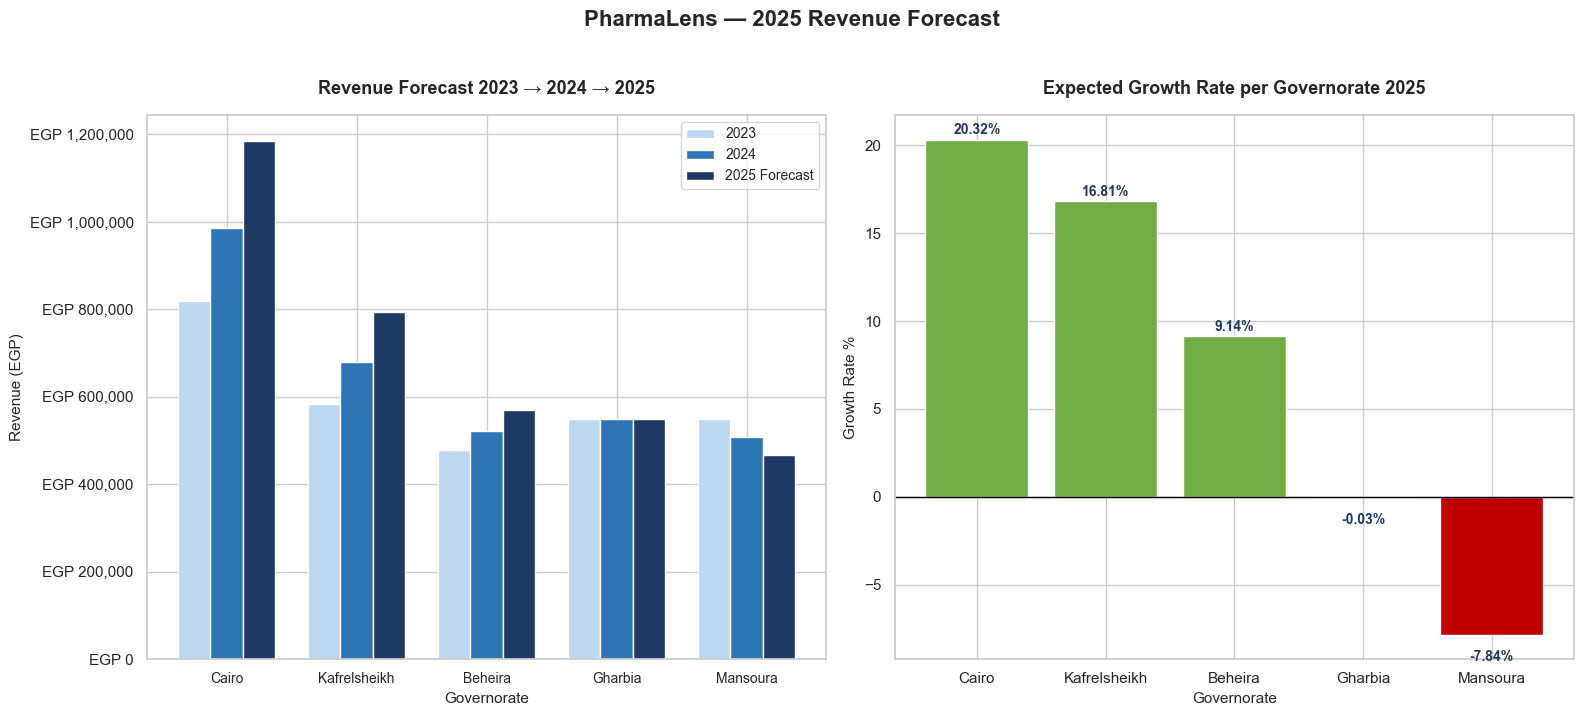

✅ Chart saved!


In [21]:
# Chart 6 — 2025 Revenue Forecast
gov_yearly = sales.groupby(["Governorate", "Year"])["Total Revenue EGP"].sum().reset_index()

forecast_data = []
for gov in gov_yearly["Governorate"].unique():
    gov_data = gov_yearly[gov_yearly["Governorate"] == gov]
    rev_2023 = gov_data[gov_data["Year"]==2023]["Total Revenue EGP"].values[0]
    rev_2024 = gov_data[gov_data["Year"]==2024]["Total Revenue EGP"].values[0]
    growth = (rev_2024 - rev_2023) / rev_2023
    rev_2025 = rev_2024 * (1 + growth)
    forecast_data.append({
        "Governorate": gov,
        "2023": rev_2023,
        "2024": rev_2024,
        "2025 Forecast": rev_2025,
        "Growth%": growth * 100
    })

forecast_df = pd.DataFrame(forecast_data).sort_values("2025 Forecast", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — 3 year comparison
x = range(len(forecast_df))
width = 0.25

axes[0].bar([i - width for i in x], forecast_df["2023"], width,
            label="2023", color="#BDD7EE", edgecolor="white")
axes[0].bar([i for i in x], forecast_df["2024"], width,
            label="2024", color="#2E75B6", edgecolor="white")
axes[0].bar([i + width for i in x], forecast_df["2025 Forecast"], width,
            label="2025 Forecast", color="#1F3864", edgecolor="white")

axes[0].set_title("Revenue Forecast 2023 → 2024 → 2025",
                  fontsize=13, fontweight="bold", pad=15)
axes[0].set_xlabel("Governorate", fontsize=11)
axes[0].set_ylabel("Revenue (EGP)", fontsize=11)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(forecast_df["Governorate"], fontsize=10)
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"EGP {v:,.0f}"))

# Right — Growth rate
colors = ["#70AD47" if g > 0 else "#C00000" for g in forecast_df["Growth%"]]
bars = axes[1].bar(forecast_df["Governorate"], forecast_df["Growth%"],
                   color=colors, edgecolor="white")

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2,
                height + (0.3 if height >= 0 else -1.5),
                f"{height:.2f}%", ha="center", fontsize=10,
                fontweight="bold", color="#1F3864")

axes[1].axhline(y=0, color="black", linewidth=1)
axes[1].set_title("Expected Growth Rate per Governorate 2025",
                  fontsize=13, fontweight="bold", pad=15)
axes[1].set_xlabel("Governorate", fontsize=11)
axes[1].set_ylabel("Growth Rate %", fontsize=11)

plt.suptitle("PharmaLens — 2025 Revenue Forecast",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../visuals/06_forecast_2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")

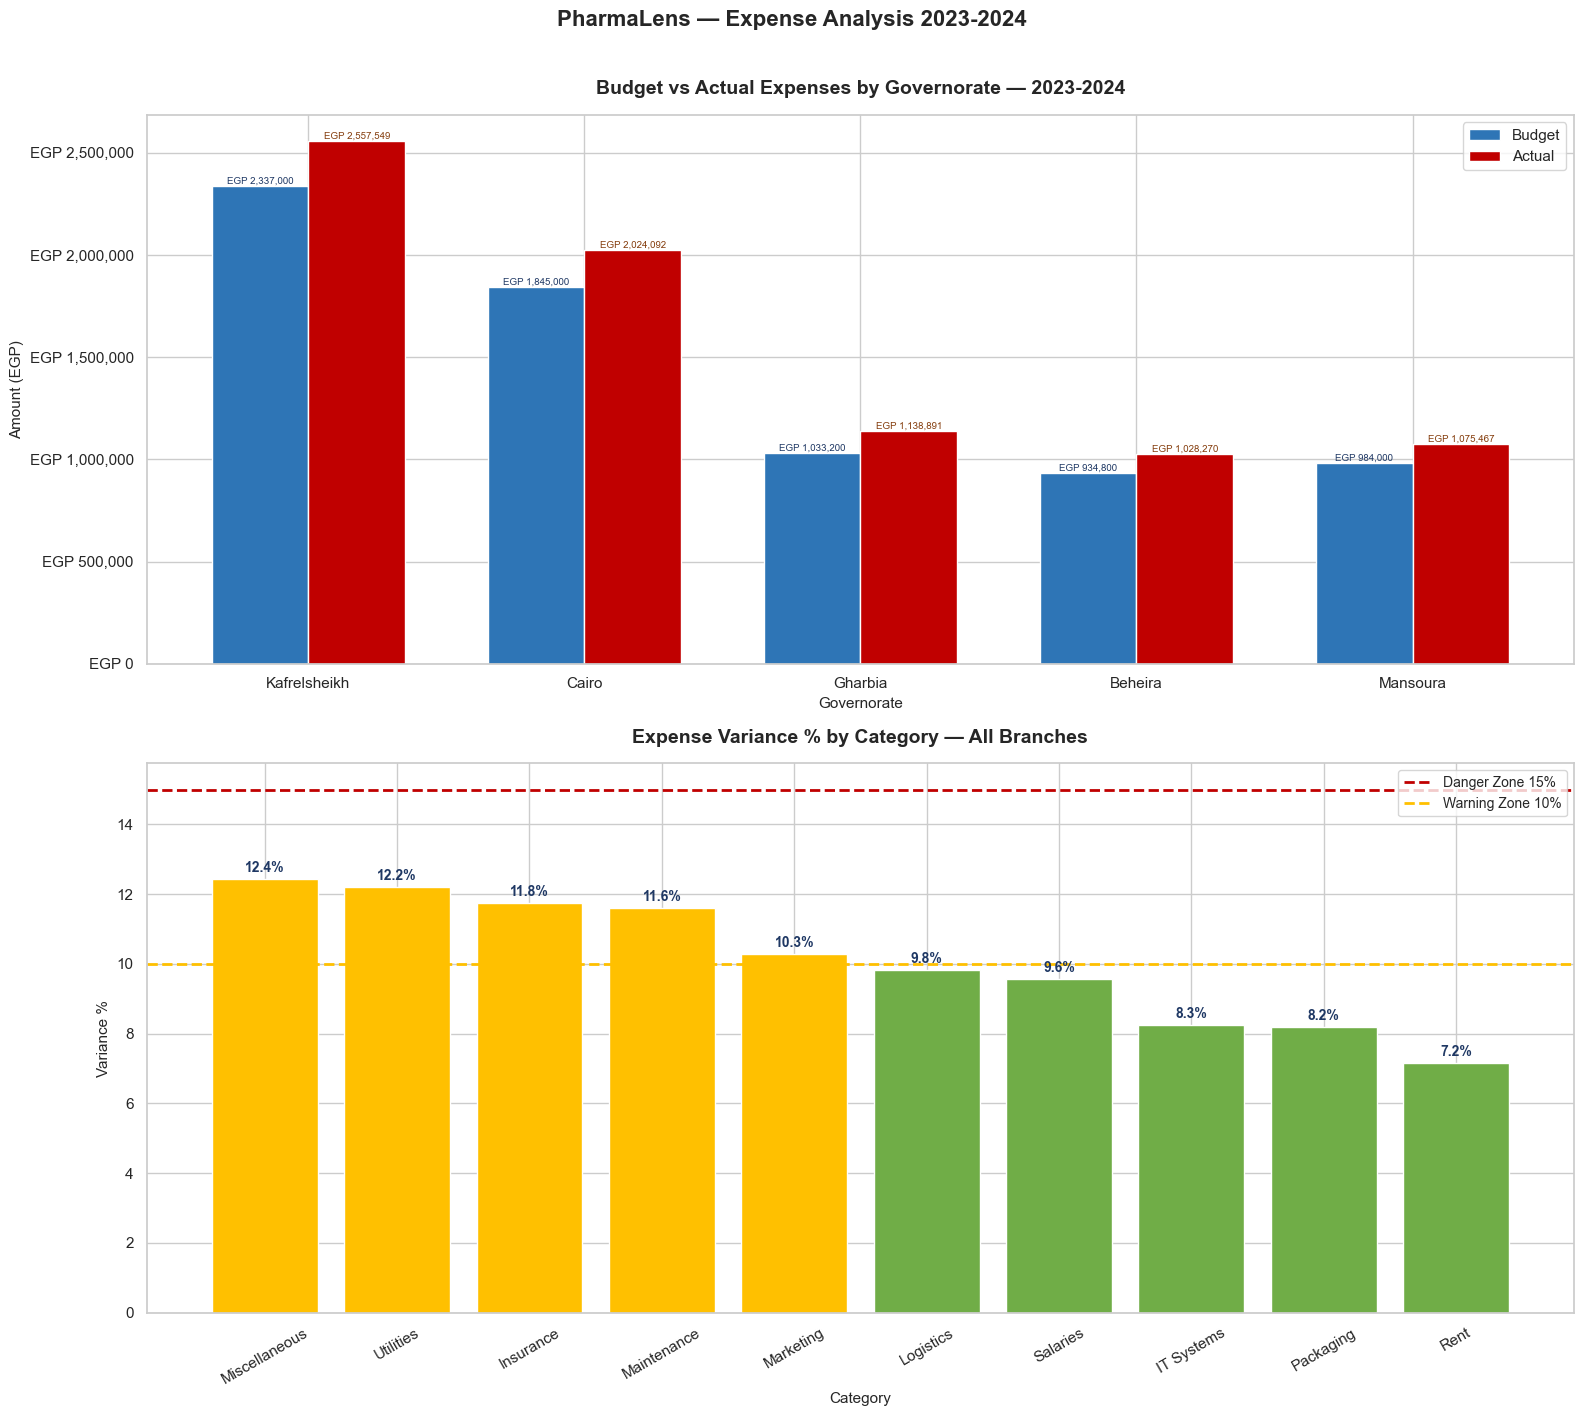

In [23]:
# Chart 7 — Expense Analysis
exp_gov = expenses.groupby(["Governorate", "Category"]).agg(
    Total_Budget=("Budget EGP", "sum"),
    Total_Actual=("Actual EGP", "sum"),
    Total_Variance=("Variance EGP", "sum")
).reset_index()

exp_gov["Variance_%"] = (exp_gov["Total_Variance"] / exp_gov["Total_Budget"]) * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# Top chart — Budget vs Actual per Governorate
exp_total = expenses.groupby(["Governorate", "Year"]).agg(
    Total_Budget=("Budget EGP", "sum"),
    Total_Actual=("Actual EGP", "sum")
).reset_index()

exp_summary = expenses.groupby("Governorate").agg(
    Total_Budget=("Budget EGP", "sum"),
    Total_Actual=("Actual EGP", "sum")
).reset_index()
exp_summary["Variance"] = exp_summary["Total_Actual"] - exp_summary["Total_Budget"]
exp_summary = exp_summary.sort_values("Variance", ascending=False)

x = range(len(exp_summary))
width = 0.35

axes[0].bar([i - width/2 for i in x], exp_summary["Total_Budget"], width,
            label="Budget", color="#2E75B6", edgecolor="white")
axes[0].bar([i + width/2 for i in x], exp_summary["Total_Actual"], width,
            label="Actual", color="#C00000", edgecolor="white")

for i, (budget, actual) in enumerate(zip(exp_summary["Total_Budget"],
                                          exp_summary["Total_Actual"])):
    axes[0].text(i - width/2, budget + 10000, f"EGP {budget:,.0f}",
                ha="center", fontsize=7, color="#1F3864")
    axes[0].text(i + width/2, actual + 10000, f"EGP {actual:,.0f}",
                ha="center", fontsize=7, color="#843C0C")

axes[0].set_title("Budget vs Actual Expenses by Governorate — 2023-2024",
                  fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Governorate", fontsize=11)
axes[0].set_ylabel("Amount (EGP)", fontsize=11)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(exp_summary["Governorate"], fontsize=11)
axes[0].legend(fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"EGP {v:,.0f}"))

# Bottom chart — Variance % by Category
exp_cat = expenses.groupby("Category").agg(
    Total_Budget=("Budget EGP", "sum"),
    Total_Actual=("Actual EGP", "sum")
).reset_index()
exp_cat["Variance_%"] = ((exp_cat["Total_Actual"] - exp_cat["Total_Budget"]) /
                          exp_cat["Total_Budget"]) * 100
exp_cat = exp_cat.sort_values("Variance_%", ascending=False)

colors = ["#C00000" if v > 15 else "#FFC000" if v > 10 else "#70AD47"
          for v in exp_cat["Variance_%"]]

bars = axes[1].bar(exp_cat["Category"], exp_cat["Variance_%"],
                   color=colors, edgecolor="white")

for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{bar.get_height():.1f}%", ha="center", fontsize=10,
                fontweight="bold", color="#1F3864")

axes[1].axhline(y=15, color="#C00000", linestyle="--",
                linewidth=2, label="Danger Zone 15%")
axes[1].axhline(y=10, color="#FFC000", linestyle="--",
                linewidth=2, label="Warning Zone 10%")
axes[1].set_title("Expense Variance % by Category — All Branches",
                  fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("Category", fontsize=11)
axes[1].set_ylabel("Variance %", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("PharmaLens — Expense Analysis 2023-2024",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../visuals/07_expense_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
